# Cross Validation

In this recitation, we will explore the effectiveness of cross validation. To do this, we will use the **Auto** dataset to observe the polynomial interaction of horsepower in predicting mpg. Essentially, we are going to be testing which of the following fits best predicts mileage,

1. Fit 1
$$\text{mpg} = \beta_0+\beta_1\text{HP}$$

2. Fit 2
$$\text{mpg} = \beta_0+\beta_1\text{HP}+\beta_2\text{HP}^2$$

3. Fit 3
$$\text{mpg} = \beta_0+\beta_1\text{HP}+\beta_2\text{HP}^2+\beta_3\text{HP}^3$$

The pattern is repeated till the 5th degree.

The parameter used for error measurement is **Mean Squared Error (MSE)**


Four techniques are discussed in this section:

1. Validation Set Approach
2. Leave One Out Validation
3. K-Fold Cross Validation
4. Bootstrap

In [1]:
#Data Wrangling
import numpy as np
import pandas as pd
import scipy.stats as sci

#Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.metrics import confusion_matrix

#Validation packages
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#Resampling
from sklearn.utils import resample

#ML Models
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

blue = '#008FD5'
red = '#FF2700'
green = '#77AB43'

plt.style.use('ggplot')
%matplotlib inline

In [2]:
auto_df = pd.read_csv("Auto.csv", na_values="?")
auto_df.dropna(inplace=True) # Removes missing values
auto_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Validation Set Approach

The validation set approach is simple, we split the training set into **two** parts. One is used for the fit, and the second is used for validation. We repeat this procedure 10 times for each fit and explore the variation in error.

In [3]:
#We cannot simply square, cube... each of the terms. This leads to interaction. We hence perform QR decomposition to
# obtain an orthogonal matrix

#To better understand this
#https://stackoverflow.com/questions/19484053/what-does-the-r-function-poly-really-do
#https://stackoverflow.com/questions/29999900/poly-in-lm-difference-between-raw-vs-orthogonal
def poly(x, p):
    x = np.array(x)
    X = np.transpose(np.vstack([x**k for k in range(p+1)]))
    return np.linalg.qr(X)[0][:,1:]

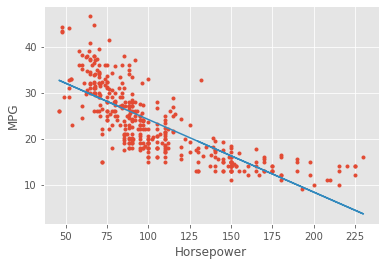

In [4]:
# We shall explore the relationship between horsepower and mpg
X = auto_df['horsepower'];
y = auto_df['mpg'];
model = LinearRegression(); #Define ML Model
x = poly(X,1);
model.fit(x,y);
y_predicted = model.predict(x);
plt.plot(X,y,'.');
plt.plot(X,y_predicted,'-');
plt.xlabel('Horsepower');
plt.ylabel('MPG');

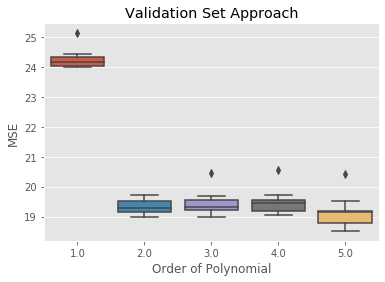

In [5]:
model = LinearRegression() #Define ML Model
score = np.array([])# array to store errors
order = np.array([]) # array to store order of polynomial

for trial in range(10):
    cv_method = KFold(n_splits=2,shuffle=True,random_state = trial) #Define CV method, KFold with 2 splits, 1 used for training and the other for testing
    for exponent in range(5):
        order = np.append(order,exponent+1)
        x = poly(X,exponent+1)
        error = -1*np.mean(cross_val_score(model,x,y,cv = cv_method,scoring = 'neg_mean_squared_error')) #Run cross validation with a score
        score = np.append(score,error)
        
sns.boxplot(x = order,y = score) # Plot results
plt.title('Validation Set Approach')
plt.xlabel('Order of Polynomial')
plt.ylabel('MSE')
plt.show()

### Leave One Out Cross Validation (LOOCV) ###


The leave one out algorithm uses n-1 samples to train the model and only one observation is used to validate the model. This procedure is repeated n times and the errors are averaged.

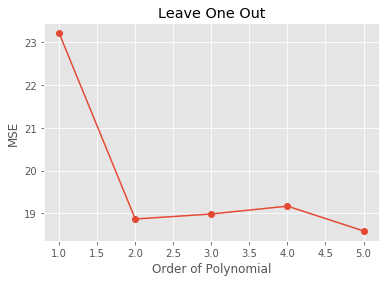

In [6]:
clf = LinearRegression()
train, test = train_test_split(auto_df,test_size = 0.2,random_state = 1)
X = train['horsepower']
y = train['mpg']
model = LinearRegression() #Define ML Model
cv_method = LeaveOneOut() #Define CV method

score = np.array([])# array to store errors
order = np.array([]) # array to store order of polynomial
for exponent in range(5):
    order = np.append(order,exponent+1)
    x = poly(X,exponent+1)
    error = -1*np.mean(cross_val_score(model,x,y,cv = cv_method,scoring = 'neg_mean_squared_error')) #Run cross validation with a score
    score = np.append(score,error)
        
plt.plot(order,score,marker = 'o') # Plot results
plt.title('Leave One Out')
plt.xlabel('Order of Polynomial')
plt.ylabel('MSE')
plt.show()

We see a sharp drop in the estimated test MSE between
the linear and quadratic fits, but then no clear improvement from using
higher-order polynomials.

### K-Fold Cross Validation ###

K-Fold cross validation splits the data into K baskets. K-1 baskets are used for training and 1 is used for testing. This procedure is repeated K times and the errors are averaged. As we can see, when K=N K-Fold cross validation is the same as leave one out.

In this example we will be using K=10.

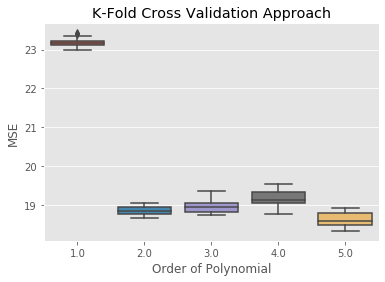

In [7]:
X = train['horsepower']
y = train['mpg']
model = LinearRegression() #Define ML Model

score = np.array([])# array to store errors
order = np.array([]) # array to store order of polynomial

for trial in range(20):
    cv_method = KFold(n_splits=10,shuffle=True,random_state = trial) #Define CV method
    for exponent in range(5):
        order = np.append(order,exponent+1)
        x = poly(X,exponent+1)
        error = -1*np.mean(cross_val_score(model,x,y,cv = cv_method,scoring = 'neg_mean_squared_error')) #Run cross validation with a score
        score = np.append(score,error)
        
sns.boxplot(x = order,y = score) # Plot results
plt.title('K-Fold Cross Validation Approach')
plt.xlabel('Order of Polynomial')
plt.ylabel('MSE')
plt.show()

### Bootstrap ###

Bootstrapping is a resampling method that allows us to obtain estimates of the Standard Error of statistics of significance. 

**Probability of an observation not appearing in the bootstrap**

If we have $n$ observations in our dataset, the bootstrap sample will also have $n$ observations samples with replacement. Using this fact, the probability of the same observation not being chosen in the entire bootstrap sample is

$$\left(\frac{n-1}{n}\right)^n$$

As the number of observations increases, approximately $\frac{1}{3}$ of the data is used as bag testing error. The rest of the derivation is left as an exercise in the homework. 

Here we will estimate the standard error of $\beta_1$ in the first degree linear regression

In [3]:
# We use numpy.polyfit to obtain a vector of first degree coefficients
coeffs = np.polyfit(auto_df['horsepower'], auto_df['mpg'], deg=1)

In [4]:
beta_ones = []
beta_zeros = []
for trial in range(20):
    # resamples with replacement the input dataset
    bootstrapped = resample(auto_df)
    
    # Remember polyfit returns polynomial coefficients with highest degree first
    beta_one = np.polyfit(bootstrapped['horsepower'], bootstrapped['mpg'], deg=1)[0]
    beta_zero = np.polyfit(bootstrapped['horsepower'], bootstrapped['mpg'], deg=1)[1]
    beta_ones.append(beta_one)
    beta_zeros.append(beta_zero)

In [15]:
# Formula for SE divides the sum of squared differences by n-1 while np.std divides by n
beta_one_SE = np.std(beta_ones) * np.sqrt((len(beta_ones) / (len(beta_ones) - 1)))
beta_zero_SE = np.std(beta_zeros) *  np.sqrt((len(beta_zeros) / (len(beta_zeros) - 1)))

In [16]:
print('The estimated SE for beta_one is', beta_one_SE ,
      '. \nThe estimated SE for beta_zero is', beta_zero_SE)

The estimated SE for beta_one is 0.0074923433641067615 . 
The estimated SE for beta_zero is 0.8228745609218467


In [17]:
np.std(beta_ones, ddof=1) # adding ddof=1 does the same thing

0.007492343364106762

In [18]:
np.std(beta_zeros, ddof=1) # adding ddof=1 does the same thing

0.8228745609218467

In [12]:
# Now let's look at the estimates for standard error using smf.ols 
fit1 = smf.ols('mpg~horsepower', data = auto_df).fit()
print(fit1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Mon, 25 May 2020   Prob (F-statistic):           7.03e-81
Time:                        10:45:34   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.0

The standard error estimates for βˆ0 and βˆ1 obtained using the formulas
from Section 3.1.2 are 0.717 for the intercept and 0.006 for the slope.
Interestingly, these are somewhat different from the estimates obtained
using the bootstrap. Does this indicate a problem with the bootstrap? In
fact, it suggests the opposite. Recall that the standard formulas given in
Equation 3.8 on page 66 rely on certain assumptions. For example, they
depend on the unknown parameter σ2, the noise variance. We then estimate
σ2 using the RSS. Now although the formula for the standard errors do not
rely on the linear model being correct, the estimate for σ2 does. We see in
Figure 3.8 on page 91 that there is a non-linear relationship in the data, and
so the residuals from a linear fit will be inflated, and so will ˆσ2. Secondly,
the standard formulas assume (somewhat unrealistically) that the xi are
fixed, and all the variability comes from the variation in the errors i. The
bootstrap approach does not rely on any of these assumptions, and so it is
likely giving a more accurate estimate of the standard errors of βˆ0 and βˆ1
than is the smf.ols().fit().summary() function.

In [13]:
# Now let's estimate SE for the quadratic fits
beta_ones = []
beta_zeros = []
beta_twos = []
for trial in range(20):
    # resamples with replacement the input dataset
    bootstrapped = resample(auto_df)
    
    # Remember polyfit returns polynomial coefficients with highest degree first
    beta_two = np.polyfit(bootstrapped['horsepower'], bootstrapped['mpg'], deg=2)[0]
    beta_one = np.polyfit(bootstrapped['horsepower'], bootstrapped['mpg'], deg=2)[1]
    beta_zero = np.polyfit(bootstrapped['horsepower'], bootstrapped['mpg'], deg=2)[2]
    beta_twos.append(beta_two)
    beta_ones.append(beta_one)
    beta_zeros.append(beta_zero)

# Formula for SE divides the sum of squared differences by n-1 while np.std divides by n
beta_two_SE = np.std(beta_twos) *  (len(beta_twos) / (len(beta_twos) - 1))
beta_one_SE = np.std(beta_ones) * (len(beta_ones) / (len(beta_ones) - 1))
beta_zero_SE = np.std(beta_zeros) *  (len(beta_zeros) / (len(beta_zeros) - 1))

print('The estimated SE for beta_two is', beta_two_SE ,
      '.\nThe estimated SE for beta_one is', beta_one_SE ,
      '. \nThe estimated SE for beta_zero is', beta_zero_SE)

The estimated SE for beta_two is 8.41928977823664e-05 .
The estimated SE for beta_one is 0.023836128499733624 . 
The estimated SE for beta_zero is 1.4974466793926686


In [14]:
# Now let's look at the estimates for standard error using smf.ols 
fit1 = smf.ols('mpg~horsepower+ I(horsepower**2)', data = auto_df).fit()
print(fit1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Mon, 25 May 2020   Prob (F-statistic):           5.40e-99
Time:                        10:45:34   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             56.9001      1

Since this model provides a good fit to the data,
there is now a better correspondence between the bootstrap estimates and
the standard estimates of SE(βˆ0), SE(βˆ1) and SE(βˆ2).

Looking at the results of the various cross validation algorithms above, we see that the validation set aproach is the least computationally expensive; however, the variation in errors is large as seen by the height of the boxplots. LOOCV is on the other extreme where the algorithm is very computationally expensive. K-Fold cross validation, attempts to obtain a middle ground between these two approaches.